# **Title: Project2**

---



**Submitted by:** Umais Siddiqui, Banu Boopalan

**Date:** 

**Course:** Data Science – DATA620

**Video Link:** 

**Github Repository:** 

#**Assignment Overview**



**Identify a large 2-node network dataset—you can start with a dataset in a repository.**

Your data should meet the criteria that it consists of ties between and not within two (or more) distinct groups.
Reduce the size of the network using a method such as the island method described in chapter 4 of social network analysis.
What can you infer about each of the distinct groups?

#Amazon Fine Foods dataset

In [1]:
import gzip
import pandas as pd

# Step 1: Read the content of the .txt.gz file
with gzip.open('finefoods.txt.gz', 'rt', encoding='utf-8', errors='ignore') as file:
    content = file.readlines()

# Step 2: Process the content to extract key-value pairs
data = []
current_record = {}
for line in content:
    line = line.strip()
    if line:
        if ': ' in line:
            key, value = line.split(': ', 1)
            current_record[key] = value
    else:
        if current_record:
            data.append(current_record)
            current_record = {}
if current_record:
    data.append(current_record)  # Add the last record if it exists

# Step 3: Create a DataFrame from the processed data
df = pd.DataFrame(data)








FileNotFoundError: [Errno 2] No such file or directory: 'finefoods.txt.gz'

In [ ]:
# Rename columns
df.rename(columns={
    'product/productId': 'productID',
    'review/userId': 'userID',
    'review/profileName': 'profileName',
    'review/helpfulness': 'helpfulness',
    'review/score': 'score',
    'review/time': 'time',
    'review/summary': 'summary',
    'review/text': 'text'

}, inplace=True)

# Display the DataFrame
print(df.head())
df.columns



    productID          userID                      profileName helpfulness  \
0  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian         1/1   
1  B00813GRG4  A1D87F6ZCVE5NK                           dll pa         0/0   
2  B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"         1/1   
3  B000UA0QIQ  A395BORC6FGVXV                             Karl         3/3   
4  B006K2ZZ7K  A1UQRSCLF8GW1T    Michael D. Bigham "M. Wassir"         0/0   

   score        time                summary  \
0    5.0  1303862400  Good Quality Dog Food   
1    1.0  1346976000      Not as Advertised   
2    4.0  1219017600  "Delight" says it all   
3    2.0  1307923200         Cough Medicine   
4    5.0  1350777600            Great taffy   

                                                text  
0  I have bought several of the Vitality canned d...  
1  Product arrived labeled as Jumbo Salted Peanut...  
2  This is a confection that has been around a fe...  
3  If you are looking for th

Index(['productID', 'userID', 'profileName', 'helpfulness', 'score', 'time',
       'summary', 'text'],
      dtype='object')

In [ ]:
# Create unique mappings
user_mapping = {user: f"U{i}" for i, user in enumerate(df['userID'].unique(), start=1)}
product_mapping = {product: f"P{i}" for i, product in enumerate(df['productID'].unique(), start=1)}

# Apply mappings to the dataframe
df['userID'] = df['userID'].map(user_mapping)
df['productID'] = df['productID'].map(product_mapping)

In [ ]:
import pandas as pd
import networkx as nx


# Create bipartite graph
G = nx.Graph()

# Add nodes with 'bipartite' attribute
G.add_nodes_from(df['userID'].unique(), bipartite=0)  # Users
G.add_nodes_from(df['productID'].unique(), bipartite=1)  # Products

# Add edges with weights (e.g., score or helpfulness)
edges = list(zip(df['userID'], df['productID'], df['score']))
G.add_weighted_edges_from(edges)

print(f"Original Graph - Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")


Original Graph - Nodes: 330317, Edges: 560804


In [ ]:
# Apply the island method (thresholding edges by weight)
threshold = 5.0  # Example threshold (tune based on data distribution)
G_island = nx.Graph((u, v, d) for u, v, d in G.edges(data=True) if d['weight'] >= threshold)

print(f"Reduced Graph - Nodes: {G_island.number_of_nodes()}, Edges: {G_island.number_of_edges()}")


Reduced Graph - Nodes: 240219, Edges: 358125


In [ ]:
degree_threshold = 3
low_degree_nodes = [node for node, degree in dict(G_island.degree()).items() if degree < degree_threshold]
G_island.remove_nodes_from(low_degree_nodes)

print(f"Filtered Graph - Nodes: {G_island.number_of_nodes()}, Edges: {G_island.number_of_edges()}")


Filtered Graph - Nodes: 54115, Edges: 171337


In [ ]:
largest_cc = max(nx.connected_components(G_island), key=len)
G_island = G_island.subgraph(largest_cc).copy()

print(f"Largest Connected Component - Nodes: {G_island.number_of_nodes()}, Edges: {G_island.number_of_edges()}")


Largest Connected Component - Nodes: 47394, Edges: 169072


In [ ]:
degree_threshold = 5
low_degree_nodes = [node for node, degree in dict(G_island.degree()).items() if degree < degree_threshold]
G_pruned = G_island.copy()
G_pruned.remove_nodes_from(low_degree_nodes)

print(f"Pruned Graph - Nodes: {G_pruned.number_of_nodes()}, Edges: {G_pruned.number_of_edges()}")


Pruned Graph - Nodes: 18372, Edges: 100994


In [ ]:
# Identify all connected components (islands)
components = list(nx.connected_components(G_pruned))

# Sort by size to identify major vs minor islands
components_sorted = sorted(components, key=len, reverse=True)

# Display key stats
print(f"Number of Islands: {len(components_sorted)}")
print(f"Size of Largest Island: {len(components_sorted[0])}")
print(f"Size of Smallest Island: {len(components_sorted[-1])}")


Number of Islands: 209
Size of Largest Island: 18030
Size of Smallest Island: 1


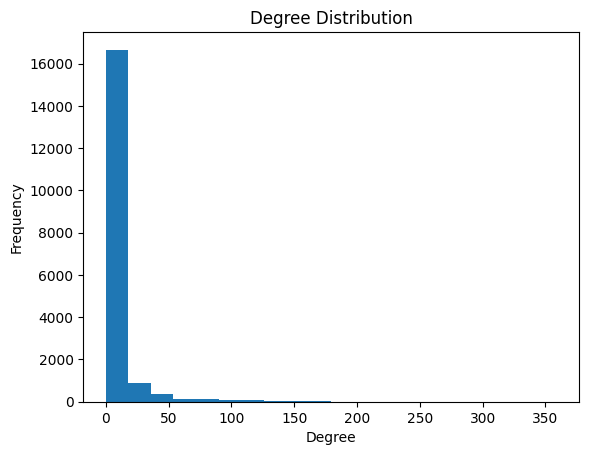

In [ ]:
import matplotlib.pyplot as plt

# Degree distribution
degrees = [d for n, d in G_pruned.degree()]
plt.hist(degrees, bins=20)
plt.title("Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.show()

In [ ]:
'''# Centrality calculations
degree_centrality = nx.degree_centrality(G_pruned)
betweenness_centrality = nx.betweenness_centrality(G_pruned)
closeness_centrality = nx.closeness_centrality(G_pruned)
eigenvector_centrality = nx.eigenvector_centrality(G_pruned, max_iter=1000)

# Convert results to a DataFrame for easier interpretation
import pandas as pd

centrality_df = pd.DataFrame({
    'Node': list(G_pruned.nodes),
    'Degree': degree_centrality.values(),
    'Betweenness': betweenness_centrality.values(),
    'Closeness': closeness_centrality.values(),
    'Eigenvector': eigenvector_centrality.values()
})

# Top 10 influential nodes
top_nodes = centrality_df.sort_values('Degree', ascending=False).head(10)
print(top_nodes)'''


KeyboardInterrupt: 